# Customer Sales Analysis (Python + Pandas)

## Problem Statement
Analyze sales data to identify revenue trends, customer behavior, and product performance.

In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("sales_data.csv")

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          1000 non-null   int64  
 1   Order_Date        1000 non-null   object 
 2   Customer_ID       1000 non-null   int64  
 3   Region            1000 non-null   object 
 4   State             1000 non-null   object 
 5   City              1000 non-null   object 
 6   Product_Category  1000 non-null   object 
 7   Product           1000 non-null   object 
 8   Quantity          1000 non-null   int64  
 9   Price             1000 non-null   int64  
 10  Discount          1000 non-null   float64
 11  Payment_Method    1000 non-null   object 
 12  Total_Sales       1000 non-null   float64
dtypes: float64(2), int64(4), object(7)
memory usage: 101.7+ KB


In [ ]:
data.describe()

In [4]:
data["Order_ID"].nunique()

1000

In [5]:
data["Customer_ID"].nunique()

100

In [6]:
data["Region"].unique()

array(['North', 'East', 'South', 'West'], dtype=object)

In [7]:
data["State"].unique()

array(['Maharashtra', 'Delhi', 'Haryana', 'Karnataka', 'UP'], dtype=object)

In [ ]:
data["City"].unique()

In [8]:
data["Product_Category"].unique()

array(['Home', 'Beauty', 'Electronics', 'Clothing'], dtype=object)

In [9]:
data.isnull().sum()

Order_ID            0
Order_Date          0
Customer_ID         0
Region              0
State               0
City                0
Product_Category    0
Product             0
Quantity            0
Price               0
Discount            0
Payment_Method      0
Total_Sales         0
dtype: int64

In [3]:
product_category_map = {"Jeans": "Clothing",
                       "Shirt": "Clothing",
                        "Cream": "Beauty",
                       "Sofa": "Home",
                       "Laptop": "Electronics",
                        "Phone" :"Electronics"}
data["Product_Category"] = data["Product"].map(product_category_map)

In [4]:
data.groupby("Product")["Product_Category"].nunique()

Product
Cream     1
Jeans     1
Laptop    1
Phone     1
Shirt     1
Sofa      1
Name: Product_Category, dtype: int64

In [5]:
state_city_map = {"Bangalore" : "Karnataka",
                  "Delhi": "Delhi",
                  "Gurgaon":"Haryana",
                  "Noida":"UP",
                  "Mumbai":"Maharashtra"}
data["State"] = data["City"].map(state_city_map)

In [6]:
data.groupby("City")["State"].unique()

City
Bangalore      [Karnataka]
Delhi              [Delhi]
Gurgaon          [Haryana]
Mumbai       [Maharashtra]
Noida                 [UP]
Name: State, dtype: object

In [7]:
state_region_map = {"Haryana": "North",
                    "Delhi": "North",
                    "Karnataka": "South",
                    "UP":"North",
                    "Maharashtra": "West"}
                    
data["Region"] = data["State"].map(state_region_map )

In [8]:
data.groupby("State")["Region"].unique()

State
Delhi          [North]
Haryana        [North]
Karnataka      [South]
Maharashtra     [West]
UP             [North]
Name: Region, dtype: object

 ####  Load the dataset & Show first 5 and last 5 rows 

In [9]:
data = pd.read_csv("sales_data.csv")
data.head()

,Order_ID,Order_Date,Customer_ID,Region,State,City,Product_Category,Product,Quantity,Price,Discount,Payment_Method,Total_Sales
0,1,2023-04-13,1004,North,Maharashtra,Bangalore,Home,Jeans,1,7882,0.26,COD,5832.68
1,2,2024-03-11,1032,North,Delhi,Delhi,Beauty,Sofa,3,16649,0.16,Card,41955.48
2,3,2025-05-10,1064,East,Haryana,Delhi,Electronics,Cream,3,49139,0.14,Card,126778.62
3,4,2023-09-28,1017,North,Karnataka,Bangalore,Clothing,Laptop,3,46541,0.03,UPI,135434.31
4,5,2023-04-17,1095,North,Haryana,Gurgaon,Electronics,Shirt,2,1492,0.19,Card,2417.04


#### Check data types of all columns 

In [47]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          1000 non-null   int64  
 1   Order_Date        1000 non-null   object 
 2   Customer_ID       1000 non-null   int64  
 3   Region            1000 non-null   object 
 4   State             1000 non-null   object 
 5   City              1000 non-null   object 
 6   Product_Category  1000 non-null   object 
 7   Product           1000 non-null   object 
 8   Quantity          1000 non-null   int64  
 9   Price             1000 non-null   int64  
 10  Discount          1000 non-null   float64
 11  Payment_Method    1000 non-null   object 
 12  Total_Sales       1000 non-null   float64
dtypes: float64(2), int64(4), object(7)
memory usage: 101.7+ KB


#### Find total number of rows and columns 

In [48]:
data.shape

(1000, 13)

#### •	Check for missing values 

In [6]:
data.isnull().sum()

Order_ID            0
Order_Date          0
Customer_ID         0
Region              0
State               0
City                0
Product_Category    0
Product             0
Quantity            0
Price               0
Discount            0
Payment_Method      0
Total_Sales         0
dtype: int64

#### Get summary statistics (describe) 

In [49]:
data.describe()

,Order_ID,Customer_ID,Quantity,Price,Discount,Total_Sales
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,1049.09100,2.465000,25156.753000,0.149970,53036.698660
std,288.819436,29.24274,1.098172,14231.115266,0.087941,41249.780247
min,1.000000,1000.00000,1.000000,567.000000,0.000000,482.250000
25%,250.750000,1024.00000,1.000000,12978.250000,0.070000,19445.400000
50%,500.500000,1049.50000,2.000000,24953.500000,0.150000,41966.640000
75%,750.250000,1074.00000,3.000000,37774.000000,0.230000,78129.090000
max,1000.000000,1099.00000,4.000000,49995.000000,0.300000,192665.280000


#### Count unique values in each column

In [50]:
data.nunique()

Order_ID            1000
Order_Date           615
Customer_ID          100
Region                 3
State                  5
City                   5
Product_Category       4
Product                6
Quantity               4
Price                994
Discount              31
Payment_Method         3
Total_Sales         1000
dtype: int64

#### •	Convert Order_Date to datetime

In [3]:
data["Order_Date"]= pd.to_datetime(data["Order_Date"])

In [52]:
data.head()

,Order_ID,Order_Date,Customer_ID,Region,State,City,Product_Category,Product,Quantity,Price,Discount,Payment_Method,Total_Sales
0,1,2023-04-13,1004,South,Karnataka,Bangalore,Clothing,Jeans,1,7882,0.26,COD,5832.68
1,2,2024-03-11,1032,North,Delhi,Delhi,Home,Sofa,3,16649,0.16,Card,41955.48
2,3,2025-05-10,1064,North,Delhi,Delhi,Beauty,Cream,3,49139,0.14,Card,126778.62
3,4,2023-09-28,1017,South,Karnataka,Bangalore,Electronics,Laptop,3,46541,0.03,UPI,135434.31
4,5,2023-04-17,1095,North,Haryana,Gurgaon,Clothing,Shirt,2,1492,0.19,Card,2417.04


In [53]:
data["Order_Date"].dtype

dtype('<M8[ns]')

#### Check and remove duplicate rows

In [54]:
data.duplicated().sum()

np.int64(0)

#### •	Ensure Price, Quantity, Discount are numeric

In [11]:
data.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Region', 'State', 'City',
       'Product_Category', 'Product', 'Quantity', 'Price', 'Discount',
       'Payment_Method', 'Total_Sales'],
      dtype='object')

In [12]:
data["Quantity"].dtype
data["Price"].dtype
data["Discount"].dtype

dtype('float64')

#### Create a new column:
#### -	Revenue = Quantity * Price
#### -  Verify if Total_Sales is calculated correctly


In [13]:
data.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Region', 'State', 'City',
       'Product_Category', 'Product', 'Quantity', 'Price', 'Discount',
       'Payment_Method', 'Total_Sales'],
      dtype='object')

In [4]:
data["Revenue"] = data["Quantity"]* data["Price"]*(1 - data["Discount"])

In [56]:
data.head()

,Order_ID,Order_Date,Customer_ID,Region,State,City,Product_Category,Product,Quantity,Price,Discount,Payment_Method,Total_Sales,Revenue
0,1,2023-04-13,1004,South,Karnataka,Bangalore,Clothing,Jeans,1,7882,0.26,COD,5832.68,5832.68
1,2,2024-03-11,1032,North,Delhi,Delhi,Home,Sofa,3,16649,0.16,Card,41955.48,41955.48
2,3,2025-05-10,1064,North,Delhi,Delhi,Beauty,Cream,3,49139,0.14,Card,126778.62,126778.62
3,4,2023-09-28,1017,South,Karnataka,Bangalore,Electronics,Laptop,3,46541,0.03,UPI,135434.31,135434.31
4,5,2023-04-17,1095,North,Haryana,Gurgaon,Clothing,Shirt,2,1492,0.19,Card,2417.04,2417.04


In [5]:
data["check"] = data["Revenue"] == data["Total_Sales"]
data["check"]

0       True
1      False
2       True
3       True
4       True
       ...  
995     True
996     True
997     True
998     True
999     True
Name: check, Length: 1000, dtype: bool

In [59]:
data[["Revenue","Total_Sales"]].head()

,Revenue,Total_Sales
0,5832.68,5832.68
1,41955.48,41955.48
2,126778.62,126778.62
3,135434.31,135434.31
4,2417.04,2417.04


In [60]:
invalid_data = data[data["check"] == False]
invalid_data

,Order_ID,Order_Date,Customer_ID,Region,State,City,Product_Category,Product,Quantity,Price,Discount,Payment_Method,Total_Sales,Revenue,check
1,2,2024-03-11,1032,North,Delhi,Delhi,Home,Sofa,3,16649,0.16,Card,41955.48,41955.48,False
7,8,2023-01-21,1084,North,UP,Noida,Beauty,Cream,2,27660,0.19,COD,44809.20,44809.20,False
13,14,2024-04-03,1026,North,UP,Noida,Electronics,Laptop,2,32667,0.08,COD,60107.28,60107.28,False
16,17,2023-04-10,1032,South,Karnataka,Bangalore,Electronics,Phone,2,31876,0.18,Card,52276.64,52276.64,False
20,21,2024-10-23,1020,North,UP,Noida,Clothing,Shirt,1,38739,0.22,UPI,30216.42,30216.42,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
981,982,2025-01-21,1057,South,Karnataka,Bangalore,Clothing,Jeans,4,5785,0.29,Card,16429.40,16429.40,False
982,983,2025-07-13,1066,North,Delhi,Delhi,Electronics,Phone,3,10089,0.05,COD,28753.65,28753.65,False
984,985,2024-07-11,1039,South,Karnataka,Bangalore,Home,Sofa,3,14616,0.06,COD,41217.12,41217.12,False
988,989,2024-08-16,1076,North,Haryana,Gurgaon,Beauty,Cream,2,11389,0.30,UPI,15944.60,15944.60,False


In [61]:
invalid_data[["City","Total_Sales","Revenue","check"]]

,City,Total_Sales,Revenue,check
1,Delhi,41955.48,41955.48,False
7,Noida,44809.20,44809.20,False
13,Noida,60107.28,60107.28,False
16,Bangalore,52276.64,52276.64,False
20,Noida,30216.42,30216.42,False
...,...,...,...,...
981,Bangalore,16429.40,16429.40,False
982,Delhi,28753.65,28753.65,False
984,Bangalore,41217.12,41217.12,False
988,Gurgaon,15944.60,15944.60,False


In [62]:
invalid_data["Revenue"] - invalid_data["Total_Sales"]

1     -7.275958e-12
7      7.275958e-12
13     7.275958e-12
16     7.275958e-12
20     3.637979e-12
           ...     
981   -3.637979e-12
982   -3.637979e-12
984   -7.275958e-12
988   -1.818989e-12
993   -1.455192e-11
Length: 227, dtype: float64

In [6]:
import numpy as np
data["check"] = np.isclose(data["Revenue"],data["Total_Sales"])
data["check"]

0      True
1      True
2      True
3      True
4      True
       ... 
995    True
996    True
997    True
998    True
999    True
Name: check, Length: 1000, dtype: bool

#### Total sales overall

In [64]:
Total_Sales_overall = data["Total_Sales"].sum()
print(f"Total Sales Overall is {Total_Sales_overall}")

Total Sales Overall is 53036698.660000004


#### •	Total sales by:
- Region
- State
- City


In [65]:
Total_Sales_by_region = data.groupby("Region")["Total_Sales"].sum()
print("Total Sales by Region is:\n",Total_Sales_by_region,"\n")

Total_Sales_by_State = data.groupby("State")["Total_Sales"].sum()
print("Total Sales by State is:\n",Total_Sales_by_State,"\n")

Total_Sales_by_City = data.groupby("City")["Total_Sales"].sum()
print("Total Sales by City is:\n",Total_Sales_by_City,"\n")

Total Sales by Region is:
 Region
North    32490808.36
South    10552150.99
West      9993739.31
Name: Total_Sales, dtype: float64 

Total Sales by State is:
 State
Delhi          11190428.34
Haryana        10031107.09
Karnataka      10552150.99
Maharashtra     9993739.31
UP             11269272.93
Name: Total_Sales, dtype: float64 

Total Sales by City is:
 City
Bangalore    10552150.99
Delhi        11190428.34
Gurgaon      10031107.09
Mumbai        9993739.31
Noida        11269272.93
Name: Total_Sales, dtype: float64 



#### •	Average order value

In [22]:
average_order_value = data["Total_Sales"].sum()/ data["Order_ID"].nunique()
average_order_value.round(2)

np.float64(53036.7)

#### •	Total quantity sold per product

In [67]:
data.groupby("Product")["Quantity"].sum().sort_values(ascending = False)

Product
Cream     439
Jeans     432
Sofa      422
Phone     416
Shirt     406
Laptop    350
Name: Quantity, dtype: int64

#### •	Top 5 selling products by revenue

In [68]:
data.groupby("Product")["Revenue"].sum().sort_values(ascending = False).head(5).reset_index(name="Total_Revenue")

,Product,Total_Revenue
0,Phone,9800526.84
1,Jeans,9139628.17
2,Cream,9049534.96
3,Shirt,8678485.59
4,Sofa,8417558.75


#### •	Category-wise sales contribution

In [69]:
Category_wise_sales = data.groupby("Product_Category")["Total_Sales"].sum() 
Total_sales = data["Total_Sales"].sum()

Contribution = ((Category_wise_sales / Total_sales) * 100).reset_index(name = "percent_contribution")
Contribution["percent_contribution"] = Contribution["percent_contribution"].round(2).astype(str) + "%"


In [70]:
Contribution.sort_values("percent_contribution",ascending = False)

,Product_Category,percent_contribution
1,Clothing,33.6%
2,Electronics,33.47%
0,Beauty,17.06%
3,Home,15.87%


#### •	Sales by Product_Category

In [82]:
data.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Region', 'State', 'City',
       'Product_Category', 'Product', 'Quantity', 'Price', 'Discount',
       'Payment_Method', 'Total_Sales', 'Revenue', 'check'],
      dtype='object')

In [105]:
Sales_by_Product = data.groupby("Product_Category")["Total_Sales"].sum().reset_index(name = "Total Sales")
Sales_by_Product.sort_values("Total Sales",ascending = False)

,Product_Category,Total Sales
1,Clothing,17818113.76
2,Electronics,17751491.19
0,Beauty,9049534.96
3,Home,8417558.75


#### •	Sales by Region and Category

In [72]:
Catagorical_sales_region =  (
    data.groupby(["Region", "Product_Category"])["Total_Sales"]
        .sum()
        .reset_index(name = "Total Sales").sort_values(["Total Sales"],ascending = False))
Catagorical_sales_region

,Region,Product_Category,Total Sales
1,North,Clothing,11568789.48
2,North,Electronics,10738476.56
0,North,Beauty,5411103.28
3,North,Home,4772439.04
6,South,Electronics,3730868.83
9,West,Clothing,3513773.98
10,West,Electronics,3282145.80
5,South,Clothing,2735550.30
4,South,Beauty,2332135.67
11,West,Home,1891523.52


#### 	Average discount by category

In [73]:
AOD = (data.groupby("Product_Category")["Discount"].mean()
    .reset_index(name = "Average_Discount")
    .sort_values(["Average_Discount"],ascending = False)
      )
AOD["Average_Discount"] = AOD["Average_Discount"].round(2).astype(str) + "%"
AOD

,Product_Category,Average_Discount
3,Home,0.15%
1,Clothing,0.15%
2,Electronics,0.15%
0,Beauty,0.15%


#### •	City-wise highest sales.

In [74]:
Citywise_Sales = (data.groupby("City")["Total_Sales"].sum())
    
Citywise_Sales.loc[[Citywise_Sales.idxmax()]]

City
Noida    11269272.93
Name: Total_Sales, dtype: float64

#### •	Monthly sales trend

In [75]:
data.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Region', 'State', 'City',
       'Product_Category', 'Product', 'Quantity', 'Price', 'Discount',
       'Payment_Method', 'Total_Sales', 'Revenue', 'check'],
      dtype='object')

In [76]:
Monthly_Sales = (data.groupby(data["Order_Date"].dt.to_period("M"))["Total_Sales"]
    .sum().reset_index(name = "Total_Sales"))
Monthly_Sales.rename(columns={"Order_Date": "Month"}, inplace=True)
Monthly_Sales

,Month,Total_Sales
0,2023-01,1539068.88
1,2023-02,1543653.44
2,2023-03,840197.47
3,2023-04,2107161.65
4,2023-05,1575965.35
5,2023-06,1832295.03
6,2023-07,1734431.97
7,2023-08,1492565.47
8,2023-09,1698587.25
9,2023-10,1085686.74


#### 1.	Create pivot:
- a.	Rows → Region
- b.	Columns → Product_Category
- c.	Values → Total Sales


In [78]:
pivot_data = (data.pivot_table(index = "Region",columns = "Product_Category"
                               ,values = "Total_Sales",aggfunc = "sum"))
pivot_data

Product_Category,Beauty,Clothing,Electronics,Home
Region,,,,
North,5411103.28,11568789.48,10738476.56,4772439.04
South,2332135.67,2735550.30,3730868.83,1753596.19
West,1306296.01,3513773.98,3282145.80,1891523.52


#### Create pivot:
- .	Rows → Month
- .	Columns → Region
- .	Values → Revenue


In [79]:
df_pivot = data.pivot_table(index = data["Order_Date"].dt.to_period("M"),
                             columns = "Region",values = "Revenue",
                             aggfunc = "sum")
df_pivot.index.name = "Month"


In [80]:
df_pivot

Region,North,South,West
Month,,,
2023-01,815593.25,228062.34,495413.29
2023-02,767840.37,193513.07,582300.00
2023-03,454520.64,157477.98,228198.85
2023-04,1171252.65,678167.68,257741.32
2023-05,796169.68,647213.02,132582.65
2023-06,1323561.29,394799.96,113933.78
2023-07,1147220.34,208561.42,378650.21
2023-08,732677.82,294115.76,465771.89
2023-09,904890.12,464298.99,329398.14


#### 3.	Replace NaN values with 0

In [81]:
df_pivot = df_pivot.sort_index().fillna(0)
df_pivot

Region,North,South,West
Month,,,
2023-01,815593.25,228062.34,495413.29
2023-02,767840.37,193513.07,582300.00
2023-03,454520.64,157477.98,228198.85
2023-04,1171252.65,678167.68,257741.32
2023-05,796169.68,647213.02,132582.65
2023-06,1323561.29,394799.96,113933.78
2023-07,1147220.34,208561.42,378650.21
2023-08,732677.82,294115.76,465771.89
2023-09,904890.12,464298.99,329398.14


#### Orders where:
- **Sales** > 20,000  
- **Discount** > 20%


In [82]:
data[(data["Total_Sales"]>20000) & (data["Discount"]> 0.20)].sort_values("Total_Sales",ascending = False)

,Order_ID,Order_Date,Customer_ID,Region,State,City,Product_Category,Product,Quantity,Price,Discount,Payment_Method,Total_Sales,Revenue,check
850,851,2023-07-13,1028,North,Haryana,Gurgaon,Electronics,Phone,4,49125,0.22,COD,153270.00,153270.00,True
594,595,2024-09-27,1095,North,Delhi,Delhi,Beauty,Cream,4,48131,0.23,COD,148243.48,148243.48,True
890,891,2024-10-21,1055,North,Haryana,Gurgaon,Clothing,Shirt,4,47062,0.23,Card,144950.96,144950.96,True
743,744,2024-01-11,1024,North,Delhi,Delhi,Electronics,Laptop,4,47799,0.25,Card,143397.00,143397.00,True
678,679,2024-10-20,1086,North,Delhi,Delhi,Clothing,Jeans,4,47109,0.24,UPI,143211.36,143211.36,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30,31,2023-10-04,1022,West,Maharashtra,Mumbai,Electronics,Phone,1,26193,0.22,COD,20430.54,20430.54,True
734,735,2024-09-08,1072,North,UP,Noida,Home,Sofa,3,9449,0.28,COD,20409.84,20409.84,True
40,41,2023-02-28,1000,South,Karnataka,Bangalore,Clothing,Shirt,2,14365,0.29,COD,20398.30,20398.30,True
512,513,2024-05-04,1028,West,Maharashtra,Mumbai,Clothing,Shirt,1,28210,0.28,COD,20311.20,20311.20,True


#### 2.	Top 10 highest sales orders

In [83]:
duplicate_order_id = data["Order_ID"].duplicated()
duplicate_order_id

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Name: Order_ID, Length: 1000, dtype: bool

In [84]:
Highest_Sales = (data[["Order_ID","Order_Date","Region","State","City","Total_Sales"]].
    sort_values("Total_Sales",ascending = False)
    .head(10)
                ) 
Highest_Sales

,Order_ID,Order_Date,Region,State,City,Total_Sales
378,379,2024-10-20,North,UP,Noida,192665.28
372,373,2024-03-28,West,Maharashtra,Mumbai,180120.00
8,9,2024-09-06,North,UP,Noida,178971.52
571,572,2024-03-19,South,Karnataka,Bangalore,174896.40
632,633,2024-12-04,North,Delhi,Delhi,173852.16
352,353,2025-08-10,West,Maharashtra,Mumbai,171466.80
67,68,2023-11-12,West,Maharashtra,Mumbai,168842.52
595,596,2023-04-16,South,Karnataka,Bangalore,167381.76
518,519,2024-01-28,North,UP,Noida,166776.80
149,150,2025-02-11,North,Delhi,Delhi,164539.60


#### 3.	Customers who purchased more than 3 times

In [10]:
data.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Region', 'State', 'City',
       'Product_Category', 'Product', 'Quantity', 'Price', 'Discount',
       'Payment_Method', 'Total_Sales', 'Revenue', 'check'],
      dtype='object')

In [85]:
customer_orders = (data.groupby("Customer_ID")["Order_ID"]
    .count().
    reset_index(name = "Orders_Count"))
customer_orders[customer_orders["Orders_Count"]>3]


,Customer_ID,Orders_Count
0,1000,13
1,1001,8
2,1002,11
3,1003,11
4,1004,18
...,...,...
95,1095,7
96,1096,11
97,1097,18
98,1098,13


#### 4.	Orders from Gurgaon only

In [86]:
data[data["City"]== 'Gurgaon']

,Order_ID,Order_Date,Customer_ID,Region,State,City,Product_Category,Product,Quantity,Price,Discount,Payment_Method,Total_Sales,Revenue,check
4,5,2023-04-17,1095,North,Haryana,Gurgaon,Clothing,Shirt,2,1492,0.19,Card,2417.04,2417.04,True
10,11,2024-04-11,1088,North,Haryana,Gurgaon,Clothing,Jeans,1,20072,0.01,COD,19871.28,19871.28,True
11,12,2023-08-03,1085,North,Haryana,Gurgaon,Beauty,Cream,4,4636,0.08,UPI,17060.48,17060.48,True
14,15,2023-03-29,1048,North,Haryana,Gurgaon,Beauty,Cream,3,45921,0.12,COD,121231.44,121231.44,True
28,29,2023-07-11,1002,North,Haryana,Gurgaon,Home,Sofa,4,30468,0.01,Card,120653.28,120653.28,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,969,2025-05-18,1036,North,Haryana,Gurgaon,Clothing,Shirt,1,18759,0.24,COD,14256.84,14256.84,True
974,975,2025-08-16,1076,North,Haryana,Gurgaon,Home,Sofa,2,25124,0.23,UPI,38690.96,38690.96,True
976,977,2023-07-20,1039,North,Haryana,Gurgaon,Beauty,Cream,4,20745,0.24,UPI,63064.80,63064.80,True
977,978,2025-07-17,1044,North,Haryana,Gurgaon,Electronics,Phone,4,47205,0.15,COD,160497.00,160497.00,True


#### 1.	Extract:
- Year
- Month
- Day


In [7]:
data["Year"] = data["Order_Date"].dt.year

In [8]:
data["Month"] = data["Order_Date"].dt.month

In [9]:
data["Day"] = data["Order_Date"].dt.day

In [10]:
data[["Order_Date","Year","Month","Day"]]

,Order_Date,Year,Month,Day
0,2023-04-13,2023,4,13
1,2024-03-11,2024,3,11
2,2025-05-10,2025,5,10
3,2023-09-28,2023,9,28
4,2023-04-17,2023,4,17
...,...,...,...,...
995,2023-01-10,2023,1,10
996,2025-04-03,2025,4,3
997,2025-03-08,2025,3,8
998,2023-08-30,2023,8,30


#### 2.	Monthly sales trend

In [11]:
Monthly_sales_trend = (data.groupby(["Year","Month"])["Total_Sales"]
    .sum().reset_index(name = "Total_Sales")
    .sort_values(["Year","Month"]))
Monthly_sales_trend

,Year,Month,Total_Sales
0,2023,1,1539068.88
1,2023,2,1543653.44
2,2023,3,840197.47
3,2023,4,2107161.65
4,2023,5,1575965.35
5,2023,6,1832295.03
6,2023,7,1734431.97
7,2023,8,1492565.47
8,2023,9,1698587.25
9,2023,10,1085686.74


#### 3.	Identify best sales month

In [35]:
# Step 1: Group data
grouped = data.groupby(["Year","Month"])["Total_Sales"].sum()

# Step 2: Get best month (tuple)
best_month = grouped.idxmax()

# Step 3: Extract and convert to normal int
year, month = best_month
year, month = int(year), int(month)

# Step 4: Get sales value
best_sales = grouped.max()

# Final output
year, month, best_sales


(2024, 10, 2539485.89)

####	Moving average of sales (rolling mean)

In [12]:
Monthly_sales_trend["Moving_Average"] = (Monthly_sales_trend["Total_Sales"]
    .rolling(3).mean())
Monthly_sales_trend["Moving_Average"] = Monthly_sales_trend["Moving_Average"].round(2)

In [13]:
Monthly_sales_trend

,Year,Month,Total_Sales,Moving_Average
0,2023,1,1539068.88,NaN
1,2023,2,1543653.44,NaN
2,2023,3,840197.47,1307639.93
3,2023,4,2107161.65,1497004.19
4,2023,5,1575965.35,1507774.82
5,2023,6,1832295.03,1838474.01
6,2023,7,1734431.97,1714230.78
7,2023,8,1492565.47,1686430.82
8,2023,9,1698587.25,1641861.56
9,2023,10,1085686.74,1425613.15


#### Correlation between:
- Price & Quantity
- Discount & Sales


In [70]:
Correlation_price_qty = data["Price"].corr(data["Quantity"])
Correlation_price_qty

np.float64(0.025514288858983467)

#### interpretation:

- Very close to 0
- No meaningful relationship

✔️ Changing price does NOT affect quantity much

In [71]:
corr_dis_sales = data["Discount"].corr(data["Total_Sales"])
corr_dis_sales

np.float64(-0.13104147473198546)

#### Interpretation:

- Slight negative correlation
- As discount increases → Total_Sales slightly decreases
- Correlation is weak (≈ -0.13)
- So effect is not strong

#### Insight
- Price and quantity show no significant correlation,indicating demand is not price-sensitive in this dataset. 
- Discount shows a weak negative correlation with total sales,suggesting discounts are not effectively driving   revenue.

#### 1.	Bar chart: Sales by category

In [12]:
import matplotlib.pyplot as plt

In [20]:
data.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Region', 'State', 'City',
       'Product_Category', 'Product', 'Quantity', 'Price', 'Discount',
       'Payment_Method', 'Total_Sales', 'Revenue', 'check', 'Year', 'Month',
       'Day'],
      dtype='object')

In [26]:
sales = data.groupby("Product_Category")["Total_Sales"].sum().reset_index(name = "Total Sales")
sales

,Product_Category,Total Sales
0,Beauty,9049534.96
1,Clothing,17818113.76
2,Electronics,17751491.19
3,Home,8417558.75


In [ ]:
Product_category = data["Product_Category"].unique()
sales = sales["Total Sales"]
for i in range(len("Product_Category"):
    plt.text(i, sales[i], str(sales[i]), ha='center')

([0, 1, 2, 3],
 [Text(0, 0, 'Beauty'),
  Text(1, 0, 'Clothing'),
  Text(2, 0, 'Electronics'),
  Text(3, 0, 'Home')])

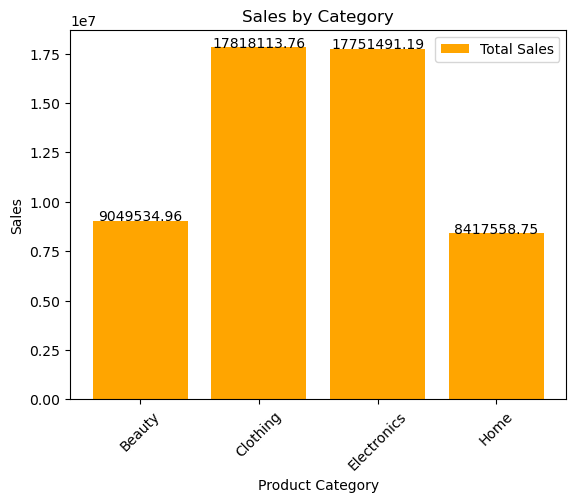

In [40]:
plt.bar(sales["Product_Category"], sales["Total Sales"],color = "orange", 
        label = "Total Sales")

for i in range(len(sales)):
    plt.text(i,
             sales["Total Sales"].iloc[i],
             str(sales["Total Sales"].iloc[i]),
             ha='center')
plt.xlabel("Product Category")
plt.ylabel("Sales")
plt.title("Sales by Category")
plt.legend()
plt.xticks(rotation=45)



#### 2.	Line chart: Monthly sales trend

In [38]:
Monthly_sales_trend.columns

Index(['Year', 'Month', 'Total_Sales', 'Moving_Average'], dtype='object')

In [61]:
Monthly_sales_trend["Date"] = pd.to_datetime(
    Monthly_sales_trend["Year"].astype(str) + "-" +
    Monthly_sales_trend["Month"].astype(str)
)

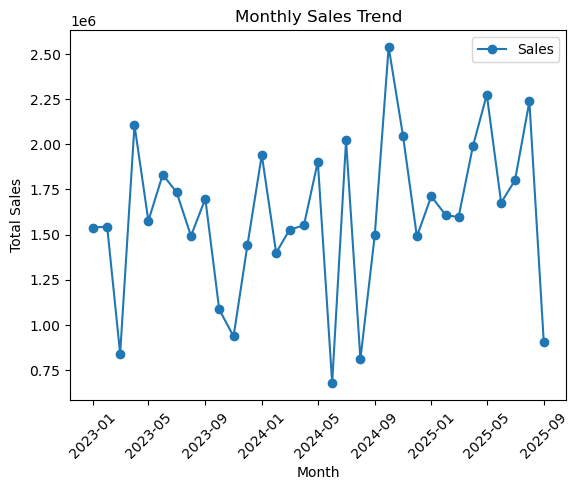

In [62]:
plt.plot(Monthly_sales_trend["Date"], Monthly_sales_trend["Total_Sales"],
         marker='o', label="Sales")

plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Monthly Sales Trend")
plt.xticks(rotation=45)
plt.legend()
plt.show()

#### 3.	Pie chart: Region contribution

In [70]:
data.groupby("Region")["Total_Sales"].sum().reset_index(name = "Total Sales")


,Region,Total Sales
0,North,32490808.36
1,South,10552150.99
2,West,9993739.31


In [103]:
region_sales = data.groupby("Region")["Total_Sales"].sum().reset_index(name = "Total Sales")
total_sales = data["Total_Sales"].sum()
contribution = ((region_sales["Total Sales"] / total_sales) * 100).round(2)
contribution

0    61.26
1    19.90
2    18.84
Name: Total Sales, dtype: float64

In [75]:
region = region_sales["Region"]
region

0    North
1    South
2     West
Name: Region, dtype: object

In [ ]:
for i in range(len(region)):
    plt.text(i, contribution[i], str(contribution[i]), ha='center')

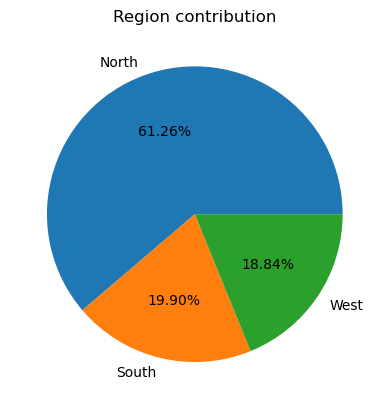

In [91]:
plt.pie(contribution,labels = region,autopct='%1.2f%%')

plt.title("Region contribution")
plt.show()

#### 4.	Histogram: Order values

In [10]:
data.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Region', 'State', 'City',
       'Product_Category', 'Product', 'Quantity', 'Price', 'Discount',
       'Payment_Method', 'Total_Sales'],
      dtype='object')

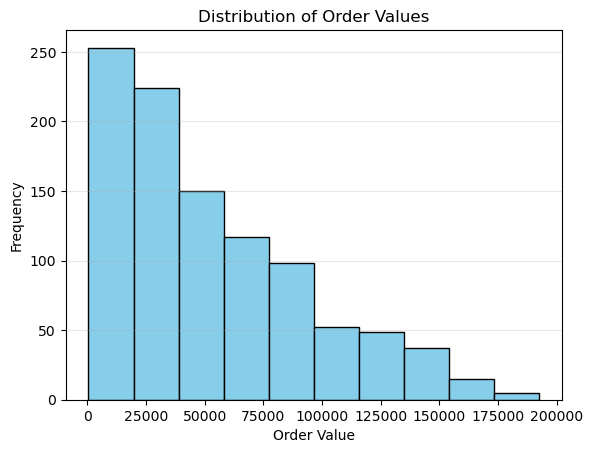

In [26]:
sales = data["Total_Sales"]
plt.hist(sales,bins =10,color="skyblue",edgecolor="black")
plt.xlabel("Order Value")
plt.ylabel("Frequency")
plt.title("Distribution of Order Values")
plt.grid(axis="y", alpha=0.3)


#### 1.Which region generates the highest revenue?

In [102]:
region_revenue = data.groupby("Region")["Revenue"].sum()
highest_revenue_region = region_revenue.idxmax()
highest_value = region_revenue.max()
print(highest_revenue_region,highest_value)

North 32490808.36


#### Which category is underperforming?

In [110]:
categories = data.groupby("Product_Category")["Total_Sales"].sum()
low_perform_category = categories.idxmin()
low_perform_category 


'Home'

#### 3.	What is the impact of discount on revenue?

In [111]:
impact = data["Discount"].corr(data["Revenue"])
impact

np.float64(-0.13104147473198546)

#### Impact of Discount on Revenue

- The correlation between discount and revenue is -0.13, which indicates a weak negative relationship.

- This means that as discounts increase, revenue tends to slightly decrease, but the relationship is very weak.

#### Insight :
<blr>   The correlation between discount and revenue is approximately -0.13, indicating a weak negative relationship. 
<blr>   This suggests that increasing discounts does not significantly boost revenue and may slightly reduce it.
<blr>   However, the relationship is weak, so discounts are not a major driver of revenue in this dataset.

#### 4.	Which city has highest average order value?

In [115]:
order_value = data.groupby("City")["Total_Sales"].mean()
city_highest_aov = order_value.idxmax()
city_highest_aov

'Noida'

#### 5.	Identify top 10 customers by revenue

In [134]:
top_10_cust = (data.groupby("Customer_ID")["Revenue"]
    .sum().reset_index(name = "Revenue" ).
    sort_values("Revenue",ascending = False))

top_10_cust.head(10)

,Customer_ID,Revenue
39,1039,1351565.08
50,1050,1146273.19
61,1061,1117744.69
24,1024,1072675.30
4,1004,1061923.90
25,1025,937691.75
86,1086,923780.32
37,1037,913375.80
55,1055,864961.12
71,1071,855210.44


#### 	Suggest which product category to focus on

In [135]:
Sales_by_Product

,Product_Category,Total Sales
0,Beauty,9049534.96
1,Clothing,17818113.76
2,Electronics,17751491.19
3,Home,8417558.75


#### Suggestion :Focus on Clothing 
- Why Clothing?
- Highest total sales → strongest revenue contributor
- Indicates high demand + good conversion
- Slightly ahead of Electronics → already winning segment